# PS4: Gradient descent and regularization
This is a fun but challenging problem set. It will test your python skills, as well as your understanding of the material in class and in the readings. Start early and debug often! Some notes:

* Part 1 is meant to be easy, so get through it quickly.
* Part 2 (especially 2.1) will be difficult, but it is the lynchpin of this problem set so make sure to do it well and understand what you've done. If you find your gradient descent algorithm is taking more than a few minutes to complete, debug more, compare notes with others, and go to the TA sessions (especially the sections on vectorized computation and computational efficiency).
* Depending on how well you've done 2.1, parts 2.3 and 4.3 will be relatively painless or incredibly painful. 
* Part 4 (especially 4.3) will be computationally intensive. Don't leave this until the last minute, otherwise your code might be running when the deadline arrives.
* Do the extra credit problems last.

---

## Introduction to the assignment

As with the last assignment, you will be using a modified version of the [California Housing Prices Dataset](https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html). Please download the csv file from bcourses ('cal_housing_data_clean_ps4.csv'). 

To perform any randomized operation, only use functions in the *numpy library (np.random)*. Do not use other packages for random functions.

In [43]:
import IPython
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib
import sklearn
import seaborn as sns

%matplotlib inline  
import matplotlib.pyplot as plt  
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.formula.api as smf

from sklearn.linear_model import Ridge

In [389]:
# Load the California Housing Dataset 
cal_df = pd.read_csv('cal_housing_data_clean_ps4.csv')

# leave the following line untouched, it will help ensure that your "random" split is the same "random" split used by the rest of the class
np.random.seed(seed=1948)

---

# Part 1: Getting oriented


### 1.1 Use existing libraries

Soon, you will write your own gradient descent algorithm, which you will then use to minimize the squared error cost function.  First, however, let's use the canned versions that come with Python, to make sure we understand what we're aiming to achieve.

Use the [Linear Regression class](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from sklearn or the [OLS class](http://wiki.scipy.org/Cookbook/OLS) from SciPy to explore the relationship between median housing value and median income in California's census block groups. 

(a) Regress the median housing value `MedHouseVal` on the median income `MedInc`. Draw a scatter plot of housing price (y-axis) against income (x-axis), and draw the regression line in blue.  You might want to make the dots semi-transparent if it improves the presentation of the figure. 

(b) Regress the median housing value on median income and median income squared.  Plot this new (curved) regression line in gold, on the same axes used for part (a). 

(c) Interpret your results.

alpha = 1.577261705168582
Beta = 0.16400595617582817


Text(0.5, 1.0, 'Median Housing Value as a function of Median Income')

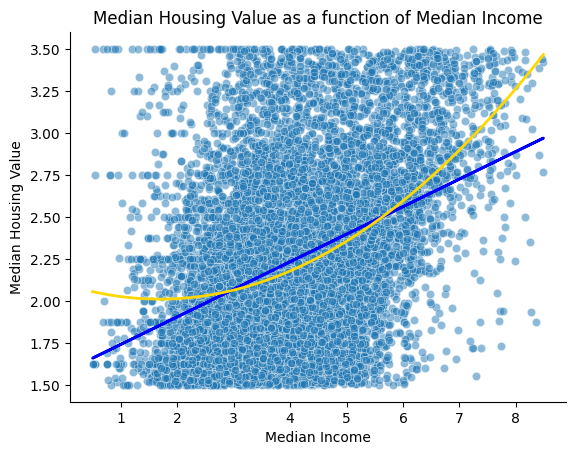

In [392]:
# Part A
# Define features and target variables 
y = cal_df['MedHouseVal'].values
X = cal_df['MedInc'].values.reshape(-1, 1)

# define model 
model = LinearRegression()
model.fit(X,y)

# Get predicted housing values using model
print( 'alpha = ' + str(model.intercept_)) 
print( 'Beta = ' + str(model.coef_[0])) 
y_pred = model.coef_[0] * X + model.intercept_

# Plot scatter of housing prices against income 
sns.scatterplot(x = cal_df['MedInc'], y = cal_df['MedHouseVal'],  alpha = 0.5)  # Scatter plot of actual data
sns.despine()
plt.plot(X, y_pred, color='blue', linewidth=2, label='Regression Line')  # Regression line
plt.xlabel('Median Income')
plt.ylabel('Median Housing Value')
plt.title('Median Housing Value as a function of Median Income')


# Part B

# define and fit model 
X2 = pd.concat([cal_df['MedInc'], cal_df['MedInc']**2], axis =1)

model2 = LinearRegression()
model2.fit(X2,y)

# make predicitions 
y_pred2 = model2.coef_[0] * X + model2.coef_[1] * X**2 + model2.intercept_
sorted_indices = np.argsort(cal_df['MedInc'])
y_pred2 = y_pred2[sorted_indices]


plt.plot(np.sort(cal_df['MedInc']), y_pred2, color='gold', linewidth=2, label='MedInc**2 Regression Line')  # Regression line
plt.xlabel('Median Income')
plt.ylabel('Median Housing Value')
plt.title('Median Housing Value as a function of Median Income')


*Part 1 Interpretation*
- Based on the scatterplot above, we performed a simple linear regression ( blue) of Median Housing values as a function of Median Income and a multivariate regression using Median Income squared (yellow). The spread of the data is large and is decently captured by the univariate linear regression. On the other hand the multivariate regression using the square of the median income  does not perform as well since the spread of the data is large and the relationship does not quite look parabolic. We may have to try using mutliple features and different degrees on each feature to build a better model for estimating Median Housing Value that captures the variance in the data.

### 1.2 Training and testing

Chances are, for the above problem you used all of your data to fit the regression line. In some circumstances this is a reasonable thing to do, but if your primary objective is prediction, you should be careful about overfitting. Let's redo the above results the ML way, using careful cross-validation.  Since you are now experts in cross-validation, and have written your own cross-validation algorithm from scratch, you can now take a shortcut and use the libraries that others have built for you.

Using the [cross-validation functions](http://scikit-learn.org/stable/modules/cross_validation.html) from scikit-learn, use 5-fold cross-validation to fit the regression model (a) from 1.1, i.e. the linear fit of median housing value on median income. Each fold of cross-validation will give you one slope coefficient and one intercept coefficient.  Create a new scatterplot of housing price against income, and draw the five different regression lines in light blue, and the original regression line from 1.1 in red (which was estimated using the full dataset). What do you notice?

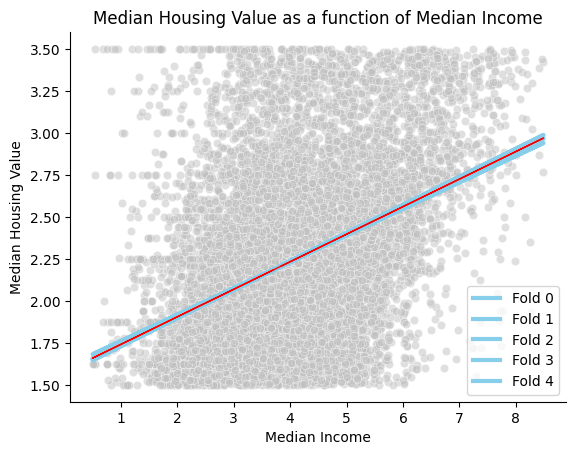

In [400]:
from sklearn.model_selection import KFold

# Initialize lists to store slope and intercept coefficients
slope_coefficients = []
intercept_coefficients = []

# Perform 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True)

# Fit regression model for each fold
for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Initialize + fit model
    model_cv = LinearRegression()
    model_cv.fit(X_train, y_train)
    
    # Store slope and intercept coefficients
    slope_coefficients.append(model_cv.coef_[0])
    intercept_coefficients.append(model_cv.intercept_)

    y_pred_cv = model_cv.coef_[0] * X_train + model_cv.intercept_
    plt.plot(X_train, y_pred_cv, color='skyblue', linewidth=3, label='Fold '+ str(i))  # Regression line

# Make scatterplot
sns.scatterplot(x = cal_df['MedInc'], y = cal_df['MedHouseVal'],  alpha = 0.5, color = 'silver')  # Scatter plot of actual data
plt.plot(X, y_pred, color='red', linewidth=1, label='Regression Line')  # Regression line
plt.xlabel('Median Income')
plt.ylabel('Median Housing Value')
plt.title('Median Housing Value as a function of Median Income')
sns.despine()


*Enter your observations here*

We notice that each of the 5 folds gives best-fit lines that "cushion" the best fit line generated from using all the data. The spread of the best fit lines from each fold is narrow and closely match the best fit line generated from using all of the data.

# Part 2: Gradient descent: Linear Regression

This is where it gets fun!

### 2.1 Implement gradient descent with one independent variable (median income)

Implement the batch gradient descent algorithm that we discussed in class. Use the version you implement to regress the median house value on the median income. Experiment with 3-4 different values of the learning rate *R*, and do the following:

* Report the values of alpha and beta that minimize the loss function
* Report the number of iterations it takes for your algorithm to converge (for each value of *R*)
* Report the total running time of your algorithm, in seconds
* How do your coefficients compare to the ones estimated through standard libraries in 1.1? Does this depend on *R*?

Some skeleton code is provided below, but you should feel free to delete this code and start from scratch if you prefer.

* *Hint 1: Don't forget to implement a stopping condition, so that at every iteration you check whether your results have converged. Common approaches to this are to (a) check to see if the loss has stopped decreasing; and (b) check if both your current parameter esimates are close to the estimates from the previous iteration.  In both cases, "close" should not be ==0, it should be <=epsilon, where epsilon is something very small (like 0.0001).*
* *Hint 2: We recommend including a MaxIterations parameter in their gradient descent algorithm, to make sure things don't go off the rails, i.e., as a safeguard in case your algorithm isn't converging as it should. *

In [399]:
import time
import random 

def bivariate_ols(xvalues, yvalues, R=0.01, MaxIterations=5000, epsilon=0.0001, **kwargs):
    """
    Function
    --------
    bivariate_ols
        Gradient Decent to minimize OLS. Used to find coefficients of bivariate OLS Linear regression

    Parameters
    ----------
    xvalues, yvalues : narray
        xvalues: independent variable
        yvalues: dependent variable
        
    R: float
        Learning rate
        
    MaxIterations: Int
        maximum number of iterations

    Epsilon:
        threshold for convergence

    Returns
    -------
    alpha: float
        intercept
        
    beta: float
        coefficient
    """
    
    start_time = time.time()
    
    # randomly initialize parameters 
    alpha = random.uniform(0, 10) # random number betwen 0 and 10 
    Beta = random.random() # random number between 0 and 1

    n = len(xvalues)

    for i in range(MaxIterations):
        # Compute predictions
        y_pred = Beta * xvalues + alpha

        # Compute gradients using partial derivatives from lecture 
        dB = (1/n) * sum(xvalues * (y_pred - yvalues))
        da = (1/n) * sum(y_pred - yvalues)

        # Update parameters
        Beta = Beta - R * dB
        alpha = alpha - R * da

        # Stopping condition: check if both  current parameter esimates are close to previous iteration estimates
        if abs(dB) <= epsilon and abs(da) <= epsilon:
            print('convergence achieved')
            break
    if i == MaxIterations -1:
        print('Max num of iterations reached ')
        
    print("Time taken: {:.2f} seconds".format(time.time() - start_time))
    return alpha, Beta, i+1


In [149]:
X = cal_df['MedInc'].values
Y = cal_df['MedHouseVal'].values

# Run 1: alpha = 0.1
a, B, num_iterations = bivariate_ols(X, Y, R=0.1)
print('Run 1 with R = 0.1: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 2: alpha = 0.08
a, B, num_iterations = bivariate_ols(X, Y, R=0.08)
print('Run 2 with R = 0.08: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 3: alpha = 0.05
a, B, num_iterations = bivariate_ols(X, Y, R=0.05)
print('Run 3 with R = 0.05: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 4: alpha = 0.02
a, B, num_iterations = bivariate_ols(X, Y, R=0.02)
print('Run 4 with R = 0.02: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))


convergence achieved
Time taken: 1.04 seconds
Run 1 with R = 0.1: Number of iterations = 959
Coefficients: alpha = 1.5783272566745565 B  = 0.1637686717619543
convergence achieved
Time taken: 1.19 seconds
Run 2 with R = 0.08: Number of iterations = 1099
Coefficients: alpha = 1.578334604003953 B  = 0.16376703560758768
convergence achieved
Time taken: 1.76 seconds
Run 3 with R = 0.05: Number of iterations = 1632
Coefficients: alpha = 1.5783408344001806 B  = 0.16376564817966066
convergence achieved
Time taken: 3.70 seconds
Run 4 with R = 0.02: Number of iterations = 3447
Coefficients: alpha = 1.5783436074920347 B  = 0.16376503064829637


**RESULTS**
1. Report the values of alpha and beta that minimize the loss function
- Run 1 with R = 0.1: 
    - alpha = 1.5783272566745565 B  = 0.1637686717619543

- Run 2 with R = 0.08: 
    - alpha = 1.5783272566745565 B  = 0.1637686717619543

- Run 3 with R = 0.05: 
    - alpha = 1.5783272566745565 B  = 0.1637686717619543

- Run 4 with R = 0.02: 
    - alpha = 1.5783272566745565 B  = 0.1637686717619543
2. Report the number of iterations it takes for your algorithm to converge (for each value of *R*)
- Run 1 with R = 0.1: Iterations: 959
- Run 2 with R = 0.08: Iterations: 1099
- Run 3 with R = 0.05: Iterations: 1632
- Run 4 with R = 0.02: Iterations: 3447

3. Report the total running time of your algorithm, in seconds
- Run 1 with R = 0.1: Time taken: 1.04 seconds
- Run 2 with R = 0.08: Time taken: 1.19 seconds
- Run 3 with R = 0.05: Time taken: 1.76 seconds
- Run 4 with R = 0.02: Time taken: 3.70 seconds
4. How do your coefficients compare to the ones estimated through standard libraries in 1.1? Does this depend on *R*?
- the coefficients are the same (when rounded to 3 decimal points) as the ones estimated by sklearn librares. The coefficients do not depend on the learning rate R, as long as the results converge before the max number of iterations is reached.

### 2.2 Data normalization (done for you!)

Soon, you will implement a version of gradient descent that can use an arbitrary number of independent variables. Before doing this, we want to give you some code to standardize your features. 

**For all the following questions, unless explicitly asked otherwise, you are expected to standardize appropriately. Recall that in settings where you are using holdout data for validation or testing purposes, this involves substracting the average and dividing by the standard deviation of your training data.**

In [172]:
def standardize(ref,tar):
    '''
    Function
    --------
    standardize
        Column-wise standardization of a target dataframe using the mean and std of a reference dataframe

    Parameters
    ----------
    ref,tar : pd.DataFrame
        ref: reference dataframe
        tar: target dataframe
        
    Returns
    -------
    tar_norm: pd.DataFrame
        Standardized target dataframe
    '''
    tar_norm = ((tar - np.mean(ref, axis = 0)) / np.std(ref, axis = 0))
    return tar_norm

# Examples
# Standardize train: standardize(ref=x_train,tar=x_train)
# Standardize test: standardize(ref=x_train,tar=x_test)

### 2.3 Implement gradient descent with an arbitrary number of independent variables

Now that you have a simple version of gradient descent working, create a version of gradient descent that can take more than one independent variable.  Assume all independent variables will be continuous.  Test your algorithm using `MedInc`, `HouseAge` and `AveRooms` as independent variables. Remember to standardize appropriately before inputting them to the gradient descent algorithm. How do your coefficients compare to the ones estimated through standard libraries?

As before,  report and interpret your estimated coefficients, the number of iterations before convergence, and the total running time of your algorithm. Experiment with three values of R (0.1, 0.01, and 0.001).

* *Hint 1: Be careful to implement this efficiently, otherwise it might take a long time for your code to run. Commands like `np.dot` can be a good friend to you on this problem*

In [191]:
def multivariate_ols(xvalue_matrix, y, R=0.01, MaxIterations=100000, epsilon=0.0001, **kwargs):
    """
    Function
    --------
    multivariate_ols
        Gradient Decent to minimize OLS. Used to find coefficients of bivariate OLS Linear regression

    Parameters
    ----------
    xvalue_matrix, yvalues : narray
        xvalue_matrix: independent variable
        yvalues: dependent variable
        
    R: float
        Learning rate
        
    MaxIterations: Int
        maximum number of iterations
        
    Returns
    -------
    alpha: float
        intercept
        
    beta_array: array[float]
        coefficient
    """
    
    start_time = time.time()

    # Get umber of features and instances
    num_features = xvalue_matrix.shape[1]
    n = len(y)

    # Randomly initialize parameters
    alpha = random.uniform(0, 10)  # Random number between 0 and 10
    beta = np.random.random(num_features)  # Random numbers between 0 and 1 for each feature
    
    for i in range(MaxIterations):
        # Compute predictions
        y_pred = np.dot(xvalue_matrix, beta) + alpha

        # Compute gradients
        dB = (1/n) * np.dot(xvalue_matrix.T, (y_pred - y))
        da = (1/n) * np.sum(y_pred - y)

        # Update parameters
        beta  = beta - R * dB
        alpha = alpha - R * da

        # Stopping condition: check if both current parameter estimates are close to previous iteration estimates
        if np.all(abs(dB) <= epsilon) and abs(da) <= epsilon:
            print('Convergence achieved')
            break

    if i == MaxIterations - 1:
        print('Max num of iterations reached')

    print("Time taken: {:.2f} seconds".format(time.time() - start_time))
    return alpha, beta, i+1

In [190]:
X_matrix_std = pd.DataFrame()
for feature in cal_df[['MedInc', 'HouseAge', 'AveRooms']]:
    X_matrix_std[feature] = standardize(cal_df[feature].values,cal_df[feature].values)

# Run 1: alpha = 0.1
a, B, num_iterations = multivariate_ols(X_matrix_std, Y, R=0.1)
print('Run 1 with R = 0.1: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 2: alpha = 0.01
a, B, num_iterations = multivariate_ols(X_matrix_std, Y, R=0.01)
print('Run 2 with R = 0.01: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 3: alpha = 0.001
a, B, num_iterations = multivariate_ols(X_matrix_std, Y, R=0.001)
print('Run 3 with R = 0.001: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))


Convergence achieved
Time taken: 0.07 seconds
Run 1 with R = 0.1: Number of iterations = 119
Coefficients: alpha = 2.245894394955366 B  = [ 0.25433689  0.08669245 -0.03073188]
Convergence achieved
Time taken: 0.21 seconds
Run 2 with R = 0.01: Number of iterations = 1098
Coefficients: alpha = 2.2459708971123913 B  = [ 0.25454775  0.08675903 -0.03090375]
Convergence achieved
Time taken: 2.02 seconds
Run 3 with R = 0.001: Number of iterations = 10453
Coefficients: alpha = 2.245972327227173 B  = [ 0.25445128  0.08682029 -0.03074695]


In [188]:
# Compare to standard libraries
model_multivariate = LinearRegression()
model_multivariate.fit(X_matrix_std,Y)
print('alpha: ' + str( model_multivariate.intercept_) + ' Betas: ' +str(model_multivariate.coef_))

alpha: 2.2458724723388017 Betas: [ 0.2544861   0.08671268 -0.0308764 ]


*PART 2.3*
1. How do your coefficients compare to the ones estimated through standard libraries?
- Using the results from all 3 runs of the multivariate gradient descent algorithm with 3 different R values, we notice the results are identical up to 3 decimal places (ie: a = 2.246, B = [0.255, 0.0868, -0.0309]). Moreover when comparing to standard libraries like sklearn, we find the results are the same up to 2-3 decimal places again. 

2. Report and interpret your estimated coefficients, the number of iterations before convergence, and the total running time of your algorithm.
- see the above output for the estimated coefficients, num of iterations and total run time for each run using R = 0.1, 0.01 and 0.001. 
- Interpretation of the coefficients: Each coefficient represent the change in the target variable for a one-unit change in the corresponding feature. The highest magnitude and positive coefficient is 'MedInc' as expected, implying a stronger relationship with MedHouseVal. The coefficient for AveRooms is negative and small, implying this feature has a lesser effect on MedHouseVal and is inversely proportional. Likewise, HouseAge has a lesser positive effect on MedHouseVal

### 2.4 Compare standardized vs. non-standardized results

Repeat the analysis from 2.3, but this time do not standardize your variables - i.e., use the original data. Use the same three values of R (0.1, 0.01, and 0.001). What do you notice about the running time and convergence properties of your algorithm? Compare to the results you would obtain using standard libraries. 

In [197]:
# Your code here

X_matrix = cal_df[['MedInc', 'HouseAge', 'AveRooms']].values

# Run 1: alpha = 0.1
a, B, num_iterations = multivariate_ols(X_matrix, Y, R=0.1, MaxIterations=500000)
print('Run 1 with R = 0.1: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 2: alpha = 0.01
a, B, num_iterations = multivariate_ols(X_matrix, Y, R=0.01, MaxIterations=500000)
print('Run 1 with R = 0.01: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Run 3: alpha = 0.001
a, B, num_iterations = multivariate_ols(X_matrix, Y, R=0.001, MaxIterations=500000)
print('Run 1 with R = 0.001: Number of iterations = ' + str(num_iterations))
print('Coefficients: alpha = ' + str(a) + ' B  = ' +str(B))

# Compare to standard libraries
model_mulit_non = LinearRegression()
model_mulit_non.fit(X_matrix,Y)
print('alpha: ' + str( model_mulit_non.intercept_) + ' Betas: ' +str(model_mulit_non.coef_))


/opt/miniconda3/envs/jupyterlab-debugger/lib/python3.10/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/h2/f6mv713s3vn7jn_ycf5srkt40000gp/T/ipykernel_59204/439545260.py:48: RuntimeWarning: invalid value encountered in subtract
  beta  = beta - R * dB
/var/folders/h2/f6mv713s3vn7jn_ycf5srkt40000gp/T/ipykernel_59204/439545260.py:49: RuntimeWarning: invalid value encountered in scalar subtract
  alpha = alpha - R * da


Max num of iterations reached
Time taken: 41.10 seconds
Run 1 with R = 0.1: Number of iterations = 500000
Coefficients: alpha = nan B  = [nan nan nan]
Max num of iterations reached
Time taken: 40.88 seconds
Run 1 with R = 0.01: Number of iterations = 500000
Coefficients: alpha = nan B  = [nan nan nan]
Convergence achieved
Time taken: 14.50 seconds
Run 1 with R = 0.001: Number of iterations = 183827
Coefficients: alpha = 1.3443765221938697 B  = [ 0.1905178   0.00695931 -0.01357706]
alpha: 1.3420030069126136 Betas: [ 0.19077902  0.00698801 -0.01350345]


*Results 2.4*

1. What do you notice about the running time and convergence properties of your algorithm? 
- The algorithm does not converge for any of the 3 R values, even when increasing the number of MaxIterations from 100000 to 500000. The run time becomes very large since it reaches the max number of iterations. 
2. Compare to the results you would obtain using standard libraries. 
- comparing this with the result from standard libraries, here there is convergence on final set of coefficients, but the run time is also slightly longer vs not standardizing.


# 3. Prediction

Let's use our fitted model to make predictions about housing prices. 

### 3.1 Cross-Validation

Unless you were careful above, you probably overfit your data again. Let's fix that. Use 5-fold cross-validation to re-fit the multivariate regression from 2.3 above, and report your estimated coefficients (there should be four, corresponding to the intercept and the three coefficients for `MedInc` and `AveRoomsNorm`, `HouseAgeNorm`). Since there are 5 folds, there will be 5 sets of four coefficients -- report them all in a 5x4 table.

**Note:** You can use KFold to perform the cross-validation. 

In [225]:
def compute_rmse(predictions, yvalues):
    P = np.array(predictions)
    Y = np.array(yvalues)
    rmse = ((P-Y)**2).sum()*1.0 / len(P) 
    rmse = np.sqrt(rmse)
    return rmse

In [401]:
# Select features to be used in K-fold split
X_matrix = cal_df[['MedInc', 'HouseAge', 'AveRooms']]

# Select target 
y = cal_df['MedHouseVal']

# Define number of splits 
num_splits = 5

# Initialize tables to store slope and intercept coefficients
coeffs = pd.DataFrame(columns = ['alpha','B_MedInc', 'B_HouseAge', 'B_AveRooms'], index = ['Fold'+ str(n) for n in range(num_splits)])
RMSE_all = pd.DataFrame(index = ['Fold'+ str(n) for n in range(num_splits)], columns = ['RMSE'])

# Perform 5-fold cross-validation
kf = KFold(n_splits=num_splits, shuffle=True)

# Fit regression model for each fold
for i, (train_index, test_index) in enumerate(kf.split(X_matrix)):

    # Select training and test data
    X_train, X_test = X_matrix.iloc[train_index], X_matrix.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Normalize features 
    X_train_std = standardize(X_train, X_train)
    X_test_std = standardize(X_train, X_test)

    # Fit model using multivariate OLS
    a, B, _ = multivariate_ols(X_train_std.values, y_train.values, R=0.1)

    # Store slope and intercept coefficients
    coeffs.loc['Fold'+ str(i), 'alpha'] = a
    coeffs.loc['Fold'+ str(i), 'B_MedInc'] = B[0]
    coeffs.loc['Fold'+ str(i), 'B_HouseAge'] = B[1]
    coeffs.loc['Fold'+ str(i), 'B_AveRooms'] = B[2]

    # Compute RMSE on held out data 
    y_pred = a + B[0]*X_test_std['MedInc'] + B[1]*X_test_std['HouseAge'] + B[2]*X_test_std['AveRooms']
    RMSE_all.iloc[i] = compute_rmse(y_pred, y_test)



Convergence achieved
Time taken: 0.21 seconds
Convergence achieved
Time taken: 0.09 seconds
Convergence achieved
Time taken: 0.15 seconds
Convergence achieved
Time taken: 0.40 seconds
Convergence achieved
Time taken: 0.13 seconds


In [402]:
# Print coefficient table 
coeffs.head()

,alpha,B_MedInc,B_HouseAge,B_AveRooms
Fold0,2.247139,0.261651,0.092208,-0.030175
Fold1,2.242448,0.248596,0.084097,-0.030485
Fold2,2.250813,0.261429,0.085923,-0.029496
Fold3,2.244723,0.251722,0.088309,-0.033714
Fold4,2.244437,0.249775,0.083173,-0.030816


*Discuss your results here*
- The coefficient table is printed above. As you can see, we get comparable results on each of the folds with some slight variance about the mean for each of the coefficients. We can compute the RMSE to determine the validity of our model. 

### 3.2 Predicted values and RMSE

Let's figure out how accurate this predictive model turned out to be. Compute the cross-validated RMSE for each of the 5 folds above. In other words, in fold 1, use the parameters estimated on the 80% of the data to make predictions for the 20%, and calculate the RMSE for those 20%. Repeate this for the remaining folds. Report the RMSE for each of the 5-folds, and the average (mean) RMSE across the five folds. How does this average RMSE compare to the performance of your nearest neighbor algorithm from the last problem set?

In [403]:
# See code above 
RMSE_all.head()

,RMSE
Fold0,0.495709
Fold1,0.492041
Fold2,0.49493
Fold3,0.484163
Fold4,0.49388


In [404]:
mean_RMSE = RMSE_all.mean(axis=0)[0]
print('Mean RMSE across 5-fold CV: ' + str(mean_RMSE))

Mean RMSE across 5-fold CV: 0.49214471878841826


*Discuss your results here*
- comparing our results to PS3 Q2.5 with the K=5 NN algorithm using 20 fold CV ( RMSE = 0.7877), we find that using 5-fold CV multivariate OLS will result in a smaller mean RMSE (RMSE = 0.4921). This suggests a multivarate linear regression model performs better than the K = 5 NN model.


## 4 Regularization 

### 4.1 Get prepped

Step 1: Generate features consisting of all polynomial combinations of degree greater than 0 and less than or equal to 3 of the following features: `MedInc`, `HouseAge` and `AveRooms`. If you are using PolynomialFeatures of sklearn.preprocessing make sure you drop the constant polynomial feature (degree 0). You should have a total of 19 polynomial features. 

Step 2: Randomly sample 80% of your data and call this the training set, and set aside the remaining 20% as your test set.

In [405]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

# PART 1: 
# Extract the features from cal_df
X_matrix = cal_df[['MedInc', 'HouseAge', 'AveRooms']]
y = cal_df['MedHouseVal']

# Transform features to include polynomial features
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_matrix)

# Get the names of new polynomial features and remake df
poly_feature_names = poly.get_feature_names_out(['MedInc', 'HouseAge', 'AveRooms'])
X_poly = pd.DataFrame(X_poly, columns =poly_feature_names)

# PART 2: 
# Randomly sample 80% of data 
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2)



### 4.2 Complexity and overfitting?

Now, using your version of multivariate regression from 2.3, let's try to build a more complex model. **Remember to standardize appropriately!** Using the training set, regress the median house value on the polynomial features using your multivariate ols algorithm. Calculate train and test RMSE. Is this the result that you were expecting? How do these numbers compare to each other, and to the RMSE from 3.2 and nearest neighbors?

In [427]:
# Normalize features 
X_train_std = standardize(X_train, X_train)
X_test_std = standardize(X_train, X_test)

# Perform multivariate OLS using poly features 
a, B, num_iterations = multivariate_ols(X_train_std.values, y_train.values, R=0.1)


Convergence achieved
Time taken: 12.09 seconds


In [ ]:
# Calculate the training and test RMSE 
y_pred_test = a + X_test_std.mul(B, axis=1).sum(axis = 1)
y_pred_train = a + X_train_std.mul(B, axis=1).sum(axis = 1)

RMSE_test = compute_rmse(y_pred_test, y_test)
RMSE_train = compute_rmse(y_pred_train, y_train)

In [433]:
# Print RMSE for train and test 
print('RMSE_test: ' +str(RMSE_test))
print('RMSE_train: ' +str(RMSE_train))

RMSE_test: 1.3601
RMSE_train: 0.4796


*Discuss your results here*
1. Calculate train and test RMSE. Is this the result that you were expecting? How do these numbers compare to each other, and to the RMSE from 3.2 and nearest neighbors?

- The training RMSE is 0.4796, while the test RMSE is 1.360. 
- These are on the order of what was expected given we have a large number of features of different degrees and no regularization in our model. Therefore, the training RMSE should be low since there is a high degree of complexity. I would expect the model to perform poorly on held out data due to overfitting issues. 
- The training RMSE is low, comparable to the CV RMSE we got in 3.2 ( 0.4796 vs 0.4921). It is much lower than the CV RMSE obtained from the k=5 NN solution from PS3 (0.4796 vs 0.7887 ) but this is an unfair comparison since we are comparing training RMSE to CV-test RMSE. When comparing the test RMSE on held out data for this question (1.360), this new model performs much more poorly than the model in problem 3.2 and the KNN model from PS3. 

### 4.3 Ridge regularization (basic)
Incorporate L2 (Ridge) regularization into your multivariate_ols regression. Write a new version of your gradient descent algorithm that includes a regularization term "lambda" to penalize excessive complexity. 

Use your regularized regression to re-fit the model using all the polynomial features on your training data and using the value lambda = 10^4.  Report the RMSE obtained for your training data, and the RMSE obtained for your testing data.

In [434]:
def multivariate_regularized_ols(xvalue_matrix, y, R=0.01, MaxIterations=100000, lmbda=0, epsilon=0.0001, **kwargs):
    start_time = time.time()

    # Get number of features and instances
    num_features = xvalue_matrix.shape[1]
    n = len(y)

    # Randomly initialize parameters
    alpha = random.uniform(0, 10)  # Random number between 0 and 10
    beta = np.random.random(num_features)  # Random numbers between 0 and 1 for each feature
    
    for i in range(MaxIterations):
        # Compute predictions
        y_pred = np.dot(xvalue_matrix, beta) + alpha

        # Compute gradients - using lecture 09 gradient descent update rule 
        dB = (1/n) * (np.dot(xvalue_matrix.T, (y_pred - y)) + lmbda*beta)
        da = (1/n) * np.sum(y_pred - y)

        # Update parameters
        beta  = beta - R * dB
        alpha = alpha - R * da

        # Stopping condition: check if both current parameter estimates are close to previous iteration estimates
        if np.all(abs(dB) <= epsilon) and abs(da) <= epsilon:
            print('Convergence achieved')
            break

    if i == MaxIterations - 1:
        print('Max num of iterations reached')

    print("Time taken: {:.2f} seconds".format(time.time() - start_time))
    return alpha, beta, i+1

In [409]:

# Using Polynomial features as training data and using the value lambda = 10^4
a_reg, B_reg, num_iterations = multivariate_regularized_ols(X_train_std.values, y_train.values, R = 0.01, lmbda=10**4)

Convergence achieved
Time taken: 5.60 seconds


In [410]:
# Calculate the training and test RMSE 
y_pred_test = a_reg + X_test_std.mul(B_reg, axis=1).sum(axis = 1)
y_pred_train = a_reg + X_train_std.mul(B_reg, axis=1).sum(axis = 1)

RMSE_test = compute_rmse(y_pred_test, y_test)
RMSE_train = compute_rmse(y_pred_train, y_train)

print('RMSE_test: ' +str(RMSE_test))
print('RMSE_train: ' +str(RMSE_train))


RMSE_test: 0.48793381702719174
RMSE_train: 0.4902109875497


*Discuss your results here*
- The RMSE for the test data set was 0.4879 while the RMSE for the training  data was 0.4902. This is consistent with expectations given that now we are penalizing for large coefficients in this mutifeature model with many degrees of freedom. Therefore, we should not get overfitting, especially with such large penalization (lambda is large (10,000)) and so the RMSE for the test data set is comparable to the triaing

### 4.4: Cross-validate lambda

This is where it all comes together! Use k-fold cross-validation to select the optimal value of lambda in a regression using all the polynomial features. In other words, define a set of different values of lambda. Then, using the 80% of your data that you set aside for training, iterate through the values of lambda one at a time. For each value of lambda, use k-fold cross-validation to compute the average cross-validated RMSE for that lambda value, computed as the average across the held-out folds. You should also record the average cross-validated train RMSE, computed as the average across the folds used for training. Create a scatter plot that shows RMSE as a function of lambda. The scatter plot should have two lines: a gold line showing the cross-validated RMSE, and a blue line showing the cross-validated train RMSE.  At this point, you should not have touched your held-out 20% of "true" test data.

What value of lambda minimizes your cross-validated RMSE? Fix that value of lambda, and train a new model using all of your training data with that value of lambda (i.e., use the entire 80% of the data that you set aside in 4.1). Calculate the RMSE for this model on the 20% of "true" test data. How does your test RMSE compare to the RMSE from 3.2, 4.2, 4.3 and to the RMSE from nearest neighbors? What do you make of these results? 

Go brag to your friends about how you just implemented cross-validated ridge-regularized multivariate regression using gradient descent optimization, from scratch!

In [414]:
# Define different values of lambda + folds for CV
lambda_values = [1, 10, 100, 1000, 10000]
k = 5

# Initialize avg RMSE lists
avg_cv_test_rmse = []
avg_cv_train_rmse = []

# Split training data into k = 5 folds
kf = KFold(n_splits=k)

# Iterate over each lambda value
for lmbda in lambda_values:
    cv_test_rmse = []
    cv_train_rmse = []
    
    # Iterate over each fold
    for train_index, test_index in kf.split(X_train_std):
        # Split data into training and test sets for this fold
        X_train_fold, X_test_fold = X_train_std.iloc[train_index], X_train_std.iloc[test_index]
        y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
        
        # Train model with regularization
        a, beta, _ = multivariate_regularized_ols(X_train_fold.values, y_train_fold.values, R = 0.1, lmbda=lmbda)
        
        # Predict on training and validation sets
        y_train_pred = X_train_fold.mul(beta, axis=1).sum(axis = 1) + a
        y_test_pred = X_test_fold.mul(beta, axis=1).sum(axis = 1) + a
        
        # Compute RMSE for this fold
        train_rmse = compute_rmse(y_train_pred, y_train_fold)
        test_rmse = compute_rmse(y_test_pred, y_test_fold)
        
        cv_test_rmse.append(test_rmse)
        cv_train_rmse.append(train_rmse)
    
    # Compute average RMSE across folds for this lambda value
    avg_cv_test_rmse.append(np.mean(cv_test_rmse))
    avg_cv_train_rmse.append(np.mean(cv_train_rmse))


Convergence achieved
Time taken: 11.89 seconds
Convergence achieved
Time taken: 8.42 seconds
Convergence achieved
Time taken: 10.19 seconds
Convergence achieved
Time taken: 9.02 seconds
Convergence achieved
Time taken: 11.01 seconds
Convergence achieved
Time taken: 3.17 seconds
Convergence achieved
Time taken: 2.56 seconds
Convergence achieved
Time taken: 3.65 seconds
Convergence achieved
Time taken: 2.51 seconds
Convergence achieved
Time taken: 2.79 seconds
Convergence achieved
Time taken: 0.83 seconds
Convergence achieved
Time taken: 0.68 seconds
Convergence achieved
Time taken: 0.72 seconds
Convergence achieved
Time taken: 0.84 seconds
Convergence achieved
Time taken: 0.74 seconds
Convergence achieved
Time taken: 0.09 seconds
Convergence achieved
Time taken: 0.11 seconds
Convergence achieved
Time taken: 0.11 seconds
Convergence achieved
Time taken: 0.09 seconds
Convergence achieved
Time taken: 0.12 seconds
Convergence achieved
Time taken: 0.03 seconds
Convergence achieved
Time taken

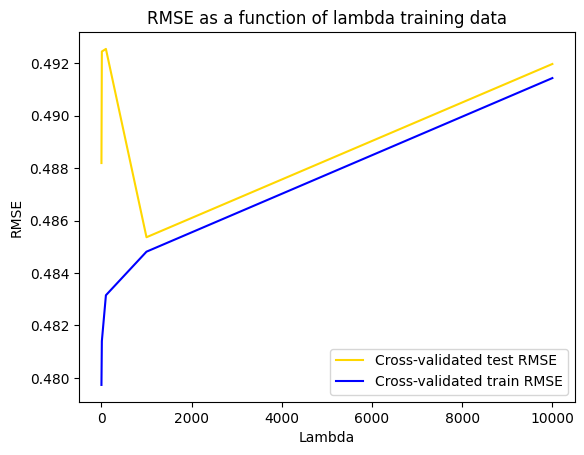

In [435]:
# Plot RMSE as a function of lambda
plt.plot(lambda_values, avg_cv_test_rmse, color='gold', label='Cross-validated test RMSE')
plt.plot(lambda_values, avg_cv_train_rmse, color='blue', label='Cross-validated train RMSE')
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.title('RMSE as a function of lambda training data')
plt.legend()


_What value of lambda minimizes your cross-validated RMSE?_
- The value of lambda that minimizes the CV-RMSE is : 1000

In [421]:

# Train model using optimal lambda -> complete training data 
optimal_l = 1000
a_optimal, B_optimal, _ = multivariate_regularized_ols(X_train_std.values, y_train.values, R = 0.1, lmbda=optimal_l)

# Calculate the RMSE using complete test data 
y_pred_test = a_optimal + X_test_std.mul(B_optimal, axis=1).sum(axis = 1)
RMSE_optimal = compute_rmse(y_pred_test, y_test)

print('RMSE_test: ' +str(RMSE_optimal))

Convergence achieved
Time taken: 0.20 seconds
RMSE_test: 0.4830648466734962


1. How does your test RMSE compare to the RMSE from 3.2, 4.2, 4.3 and to the RMSE from nearest neighbors? What do you make of these results? 
- The RMSE we obtained here is 0.4830, whereas in 3.2 with the multivariate OLS model it was 0.492144 and in 4.2 with the polynomial multivariate OLS model it was 1.3602, whereas with 4.3 with the polynomial multivariate L2 regularized OLS model it was 0.4879 compared to the K-5 NN model from PS3 which was 0.7887. This new RMSE is the lowest value of them all as a result of using k-fold CV to determine the optimal lambda that minimizes the RMSE. These results demonstrate the importance of including regularization for complex models with many features of different degrees. This method prevents overfitting as demonstrated by the minimal RMSE computed with the test held out data.

### 4.5: Compare your results to sklearn ridge [extra-credit]

Repeat your analysis in 4.4, but this time use the sklearn implementation of ridge regression (sklearn.linearmodel.Ridge). Are the results similar? How would you explain the differences, if any?

In [422]:
from sklearn.linear_model import Ridge

# Define different values of lambda + folds for CV
lambda_values = [1, 10, 100, 1000, 10000]
k = 10

# Initialize avg RMSE lists
avg_cv_test_rmse_sklearn = []
avg_cv_train_rmse_sklearn = []

# Split training data into k = 5 folds
kf = KFold(n_splits=k)

# Iterate over each lambda value
for lmbda in lambda_values:
    cv_test_rmse = []
    cv_train_rmse = []
    
    # Iterate over each fold
    for train_index, test_index in kf.split(X_train_std):
        # Split data into training and test sets for this fold
        X_train_fold, X_test_fold = X_train_std.iloc[train_index], X_train_std.iloc[test_index]
        y_train_fold, y_test_fold = y_train.iloc[train_index], y_train.iloc[test_index]
        
        # Train Ridge regression model
        ridge = Ridge(alpha=lmbda)
        ridge.fit(X_train_fold, y_train_fold)
        
        # Predict on training and test sets
        y_train_pred = ridge.predict(X_train_fold)
        y_test_pred = ridge.predict(X_test_fold)
        
        # Compute RMSE for this fold
        train_rmse = compute_rmse(y_train_pred, y_train_fold)
        test_rmse = compute_rmse(y_test_pred, y_test_fold)
        
        cv_test_rmse.append(test_rmse)
        cv_train_rmse.append(train_rmse)
    
    # Compute average RMSE across folds for this lambda value
    avg_cv_test_rmse_sklearn.append(np.mean(cv_test_rmse))
    avg_cv_train_rmse_sklearn.append(np.mean(cv_train_rmse))

print("Mean test RMSE: "+ str(avg_cv_test_rmse_sklearn))
print("Mean train RMSE: "+ str(avg_cv_train_rmse_sklearn))




Mean test RMSE: [0.5188353488337035, 0.48549499234912463, 0.4912734351999606, 0.4850839661778534, 0.4911256676402789]
Mean train RMSE: [0.4795915909154299, 0.48127854679595733, 0.48318123035685334, 0.4847458885529467, 0.49076549092499694]


In [423]:
# Train model using optimal lambda -> complete training data 
optimal_l = 1000

# Train Ridge regression model
ridge = Ridge(alpha=optimal_l)
ridge.fit(X_train_fold, y_train_fold)

# Calculate the RMSE using complete test data 
y_test_sklearn = ridge.predict(X_test_std)
RMSE_sklearn = compute_rmse(y_test_sklearn, y_test)

print('RMSE_test: ' +str(RMSE_sklearn))

RMSE_test: 0.4831409363013577


1. Are the results similar? How would you explain the differences, if any?
- The results are extremely smiliar compared to 4.4, the only difference is the computation time is signficantly shorter for the sklearn function vs  when using the function made from scratch. Here the RMSE was 0.48314 vs RMSE = 0.48306 for 4.4. which is the same to 3 decimal points. Suprisingly the home-made function had a perhaps insignificantly smaller RMSE. Any differences may be due to the epsilon convergence value they use or the number of maximum iterations used in the sklearn funciton.


### 4.6: AdaGrad [extra-credit]

AdaGrad is a method to implement gradient descent with different learning rates for each feature. Adaptive algorithms like this one are being extensively used especially in neural network training. Implement AdaGrad on 2.3 using `MedInc`, `HouseAge` and `AveRooms` as independent variables. Standardize these variables before inputting them to the gradient descent algorithm. Tune the algorithm until you estimate the regression coefficients within a tolerance of 1e-1. Use mini-batch gradient descent in this implementation. In summary for each parameter (in our case one intercept and three slopes) the update step of the gradient (in this example $\beta_j$) at iteration $k$ of the GD algorithm becomes:

$$\beta_j=\beta_j -\frac{R}{\sqrt{G^{(k)}_j}}\frac{\partial J(\alpha,\beta_1,\ldots)}{\partial \beta_j}$$ where
$G^{(k)}_j=\sum_{i=1}^{k} (\frac{\partial J^{(i)}(\alpha,\beta_1,\ldots)}{\partial \beta_j})^2$ and $R$ is your learning rate. The notation $\frac{\partial J^{(i)}(\alpha,\beta_1,\ldots)}{\partial \beta_j}$ corresponds to the value of the gradient at iteration $(i)$. Essentially we are "storing" information about previous iteration gradients. Doing  hat we effectively decrease the learning rate slower when a feature $x_i$ is sparse (i.e. has many zero values which would lead to zero gradients). Although this method is not necessary for our regression problem, it is good to be familiar with these methods as they are widely used in neural network training.  

In [ ]:
# Your code here

*Discuss your results here*